In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import math

In this notebook, the effects of ridge regression (or ridge regularization) are explored, particularly regarding how ridge regression is affected by unstandardized inputs. Ridge regression is similar to least-squares regression, except an additional penalty is added onto the error function equal to some constant multiple of the sum of the squares of each feature coefficient. This has the effect of shrinking the values of coefficients, allowing the model to disregard irrelevant features. Traditionally, lambda is used to tune how much shrinkage is added to the error calculation, though that variable is referred to as "a" throughout the notebook.

In [ ]:
#Creates a dataset with n datapoints for linear regression. Each instance has len(weights) features with an output between 0 and 1
#weights[i] indicates the scale of the ith feature (with uniform distribution between 0 and that number)
#1 - random_states[i] indicates how strongly correlated the ith feature is with the output

def generate_dataset(weights, random_states, cone, n):
  y = []
  X = []
  for i in range(n):
    inputs = []
    output = np.random.normal()
    y.append(output)
    for j in range(len(weights)):
      if output > 0.5 and not cone[j]:
        inputs.append((output * weights[j]) + ((np.random.rand() - 0.5) * 2 * (weights[j] - output) * weights[j] * random_states[j]))
      else:
        inputs.append((output * weights[j]) + ((np.random.rand() - 0.5) * 2 * output * weights[j] * random_states[j]))
    X.append(inputs)
  return X, y

In [ ]:
def generate_dataset_new(scales, importances, n):
  y = []
  X = []

  for i in range(n):
    inputs = []
    for j in range(len(scales)):
      inputs.append(scales[j] * np.random.rand())
    X.append(inputs)

  for i in range(n):
    output = 0
    for j in range(len(scales)):
      output += (importances[j] * X[i][j])
    y.append(output)

  error_pct = max(y) / 3

  for i in range(len(y)):
    y[i] = y[i] + np.random.normal(scale=error_pct)

  return X, y

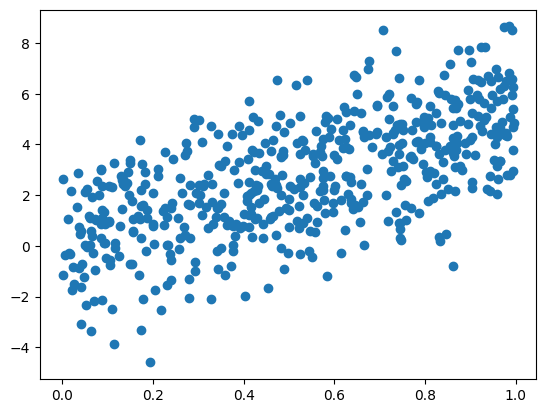

In [ ]:
scale = [1]
multiplier = [5]
X, y = generate_dataset_new(scale, multiplier, 540)
plt.scatter(X, y)
plt.show()

Using the above code, a dataset is generated with many features to predict a value between 0 and 1. To construct each input feature, the output vector is scaled by some constant multiple (noted in the 'weights' list) and each datapoint is randomly distorted by some amount from that value (the 'random_state' parameter caps the percentage of its original value a datapoint can be distorted by, controlling how closely the feature vector correlates with the output vector).

In [ ]:
#Fit a least-squares regression model, ridge regression model and standardized ridge regression model
#Return mean squared error and feature coefficients for each model

def eval_models(a_val, X, y):
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
    linear = sklearn.linear_model.LinearRegression()
    linear.fit(X_train, y_train)
    linear_guesses = linear.predict(X_test)
    linear_mse = sklearn.metrics.mean_squared_error(linear_guesses, y_test)

    ridge = sklearn.linear_model.Ridge(alpha=a_val)
    ridge.fit(X_train, y_train)
    ridge_guesses = ridge.predict(X_test)
    ridge_mse = sklearn.metrics.mean_squared_error(ridge_guesses, y_test)

    scaler = sklearn.preprocessing.StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.fit_transform(X_test)

    ridge_std = sklearn.linear_model.Ridge(alpha=a_val)
    ridge_std.fit(X_train_std, y_train)
    ridge_std_guesses = ridge_std.predict(X_test_std)
    ridge_std_mse = sklearn.metrics.mean_squared_error(ridge_std_guesses, y_test)

    return linear_mse, linear.coef_, ridge_mse, ridge.coef_, ridge_std_mse, ridge_std.coef_

In [ ]:
scales = [4,2,3,0.25,6,10000000,3]
multipliers = [1,1,1,1,1,(1/1000000000),1]
n = 2000
a = 10

X, y = generate_dataset_new(scales, multipliers, n)
outputs = eval_models(a, X, y)

print('Linear MSE: ' + str(outputs[0]))
print('Linear Coefficients: ' + str(outputs[1]))
print('Ridge MSE: ' + str(outputs[2]))
print('Ridge Coefficients: ' + str(outputs[3]))
print('Standardized Ridge MSE: ' + str(outputs[4]))
print('Standardized Ridge Coefficients: ' + str(outputs[5]))

Linear MSE: 33.2262802531852
Linear Coefficients: [1.17430359e+00 1.07290895e+00 9.65708155e-01 4.50085567e+00
 1.01850651e+00 1.70868364e-09 1.11659120e+00]
Ridge MSE: 33.232984414149975
Ridge Coefficients: [1.17005637e+00 1.04814459e+00 9.51164517e-01 2.05453026e+00
 1.02174380e+00 1.96567501e-09 1.10128585e+00]
Standardized Ridge MSE: 33.18299168073556
Standardized Ridge Coefficients: [1.38055302 0.61633756 0.82265245 0.32548809 1.72479135 0.00468387
 0.98688227]


Using the above code, a dataset is created in which one feature (feature #6) has a huge scale (values vary from 0 to 10000000), but is not a good predictor of the output (random_state = 1). In this case, ridge regression performs well (about the same as least squares), setting the corresponding coefficient extremely low, causing this irrelevant data to have minimal effect on mean squared error (MSE).

In [ ]:
scales = [4,2,3,0.25,6,0.0000001,3]
multipliers = [1,1,1,1,1,1000000000,1]
n = 2000
a = 0.01

X, y = generate_dataset_new(scales, multipliers, n)
outputs = eval_models(a, X, y)

print('Linear MSE: ' + str(outputs[0]))
print('Linear Coefficients: ' + str(outputs[1]))
print('Ridge MSE: ' + str(outputs[2]))
print('Ridge Coefficients: ' + str(outputs[3]))
print('Standardized Ridge MSE: ' + str(outputs[4]))
print('Standardized Ridge Coefficients: ' + str(outputs[5]))

Linear MSE: 1249.0725739809147
Linear Coefficients: [ 1.07711041e+00  2.14484227e+00  2.10843561e-01  3.18618018e+00
  8.39399738e-01  1.00183141e+09 -1.03439662e-01]
Ridge MSE: 2137.5290288570327
Ridge Coefficients: [  1.43778197   1.79128624   0.41855646 -14.13842417   0.87755372
   0.12558915   0.07929371]
Standardized Ridge MSE: 1249.8486269546688
Standardized Ridge Coefficients: [ 1.23819372  1.23263382  0.18191339  0.23237291  1.4658767  28.07546537
 -0.08893427]


The above code stresses the capacities of ridge regression by creating a dataset in which one feature (feature #6) has a tiny scale (values vary from 0 to 0.0000001), but is a great predictor of the output (random_state = 0.1). This stresses the method because the least-squares error would prioritize a large coefficient for feature 6 (to ofset the scale difference and to place importance on this good predictor), but the ridge error calculation rewards small coefficients. When evaluating the models, it can be seen that least squares regression performs well by weighing feature 6 roughly 10^9 times as much as the other predictors. In contrast, the ridge regularization shrinks the coefficient value to be smaller than the rest, disregarding this valuable information and thereby performing worse. By standardizing the inputs before training the model, coefficient #6 is rightfully weighted heavier than the rest, restoring the ridge regression to a similar level of efficacy as least squares.

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.02164e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.31962e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.4942e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.024e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.97698e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


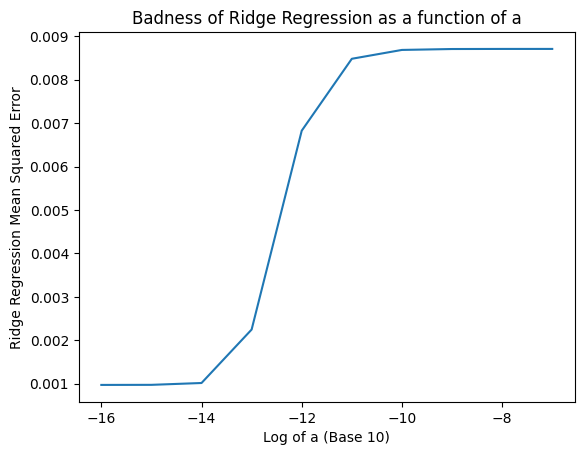

In [ ]:
weights = [4,2,3,0.25,6,0.0000001,3]
random_states = [0.8,0.7,0.9,0.6,0.75,0.1,0.65]
n = 2000
a_val = 0.0000001

a_vals = []
mses = []

a, b, c, d, = generate_dataset(weights, random_states, n)

for i in range(10):
  a_vals.append(math.log10(a_val))
  mses.append(eval_models(a_val, a, b, c, d)[2])
  a_val = a_val / 10

plt.plot(a_vals,mses)
plt.xlabel('Log of a (Base 10)')
plt.ylabel('Ridge Regression Mean Squared Error')
plt.title('Badness of Ridge Regression as a function of a')
plt.show()

By gradually reducing the a-value (the amount of shrinkage introduced into the error calculation), the over-shrinkage of a valuable coefficient is reduced, causing the ridge model to perform closer to least squares. In the above case, ridge regression begins to perform similarly to least squares at an a-value of 10^-14 or lower (note a logarithmic scale is used to better represent data). However, this is largely based on the specific discrepancy between feature magnitudes, so this finding is generalized below.

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.99303e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.28774e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.1721e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]


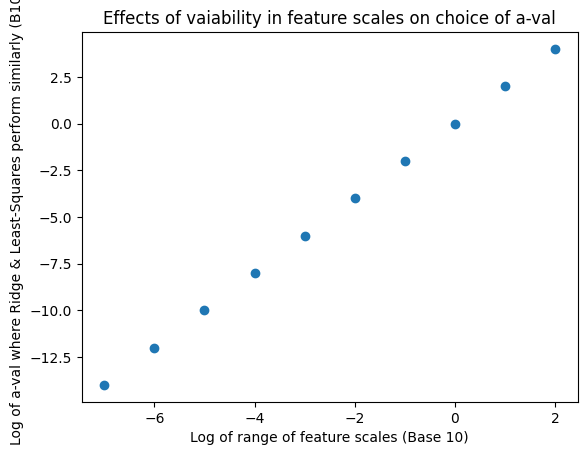

In [ ]:
x = 0.0000001

random_states = [0.8,0.7,0.9,0.6,0.75,0.1,0.65]
n = 2000

a_vals = []
x_vals = []
coef = []

for i in range(10):
  weights = [4,2,3,0.25,6,x,3]
  a, b, c, d, = generate_dataset(weights, random_states, n)
  a_val = 10000000
  x_vals.append(math.log10(x))
  while True:
    output = eval_models(a_val, a, b, c, d)
    if output[2] < (1.5 * output[0]):
      a_vals.append(math.log10(a_val))
      break
    else:
      a_val = a_val / 10
  try:
    coef.append(math.log10(a_val)/math.log10(x))
  except:
    pass
  x = x * 10

print(coef)

plt.scatter(x_vals,a_vals)
plt.xlabel('Log of range of feature scales (Base 10)')
plt.ylabel('Log of a-val where Ridge & Least-Squares perform similarly (B10)')
plt.title('Effects of vaiability in feature scales on choice of a-val')
plt.show()

In the code above, the magnitude of the key feature is varied, with the ridge model being retrained with various a-values. On the x-axis of the above plot is the number of orders of magnitude separating the largest and smallest features in the dataset (ex. if all features range from 0-5, x=0, though if one feature ranges from 0-5000, x=3), and the y-axis presents the log of the a-value below which ridge and least squares regression perform similarly. From the above graph, it can be seen for this specific dataset, the "crossover point" a-value occurs at roughly twice the number of orders of magnitude separating the key feature from the rest of the features of the dataset. Symbolically, a* = (10^x)^2.

While much more investigation is needed to understand exactly how ridge regression struggles with unstandardized data at different levels of shrinkage, it can be seen that ridge regression struggles to pick out important features for a model when the magnitude of those features is small. This does a good job of highlighting the importance of data standardization for machine learning, and serves as a cautionary example that while ridge regression is good at filtering out irrelevant data, it also may filter out important information as well.